# Neural Network to Recognise Digits

In [1]:
# importing packages
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
print("import success")

import success


In [2]:
print(torch.cuda.is_available())

True


In [3]:
df = pd.read_csv("train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Split Data

In [4]:
from sklearn.model_selection import train_test_split
print("import success")

import success


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df.drop(labels=["label"], axis=1), df["label"], test_size = 0.2, random_state = 42
)

X_train = torch.tensor(X_train_raw.values, dtype=torch.float32)
X_test = torch.tensor(X_test_raw.values, dtype=torch.float32)
y_train = torch.tensor(y_train_raw.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test_raw.values, dtype=torch.float32).view(-1, 1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

torch.Size([33600, 784]) torch.Size([33600, 1])
torch.Size([8400, 784]) torch.Size([8400, 1])


## Create Model

In [6]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU()
        self.layer1 = nn.Linear(784, 1000)
        self.layer2 = nn.Linear(1000, 1000)
        self.layer3 = nn.Linear(1000, 900)
        self.layer4 = nn.Linear(900, 800)
        self.layer5 = nn.Linear(800, 700)
        self.layer6 = nn.Linear(700, 600)
        self.layer7 = nn.Linear(600, 500)
        self.layer8 = nn.Linear(500, 250)
        self.layer9 = nn.Linear(250, 100)
        self.layer10 = nn.Linear(100, 50)
        self.output = nn.Linear(50, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)
        x = self.relu(x)
        x = self.layer4(x)
        x = self.relu(x)
        x = self.layer5(x)
        x = self.relu(x)
        x = self.layer6(x)
        x = self.relu(x)
        x = self.layer7(x)
        x = self.relu(x)
        x = self.layer8(x)
        x = self.relu(x)
        x = self.layer9(x)
        x = self.relu(x)
        x = self.layer10(x)
        x = self.relu(x)
        x = self.output(x)
        return x

In [7]:
model = NeuralNetwork().to(device)
# model = NeuralNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [8]:
epochs = 1001

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train.squeeze().long())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if not epoch % 10: 
        print(f'Epoch {epoch}: Loss = {loss.item():.4f}')

Epoch 0: Loss = 2.3067
Epoch 10: Loss = 2.3063
Epoch 20: Loss = 2.3058
Epoch 30: Loss = 2.3054
Epoch 40: Loss = 2.3049
Epoch 50: Loss = 2.3045
Epoch 60: Loss = 2.3040
Epoch 70: Loss = 2.3036
Epoch 80: Loss = 2.3031
Epoch 90: Loss = 2.3027
Epoch 100: Loss = 2.3022
Epoch 110: Loss = 2.3017
Epoch 120: Loss = 2.3011
Epoch 130: Loss = 2.3006
Epoch 140: Loss = 2.3000
Epoch 150: Loss = 2.2994


KeyboardInterrupt: 

## Model Evaluation

In [22]:
model.eval()

with torch.no_grad():
    test_outputs = model(X_test)  # output is 8400 by 10

    _, predictions = torch.max(test_outputs, dim=1)  # finds the maximum probability in the row (dim=1) then get the label

    pred_np = predictions.detach().cpu().numpy()
    y_test_np = y_test.cpu().detach().numpy().flatten()

print(pred_np.shape)
print(y_test_np.shape)

(8400,)
(8400,)


In [23]:
accuracy = (pred_np == y_test_np).mean()
print(f"Total Accuracy: {accuracy * 100:.2f}%")

Total Accuracy: 90.02%


In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print("import success")

import success


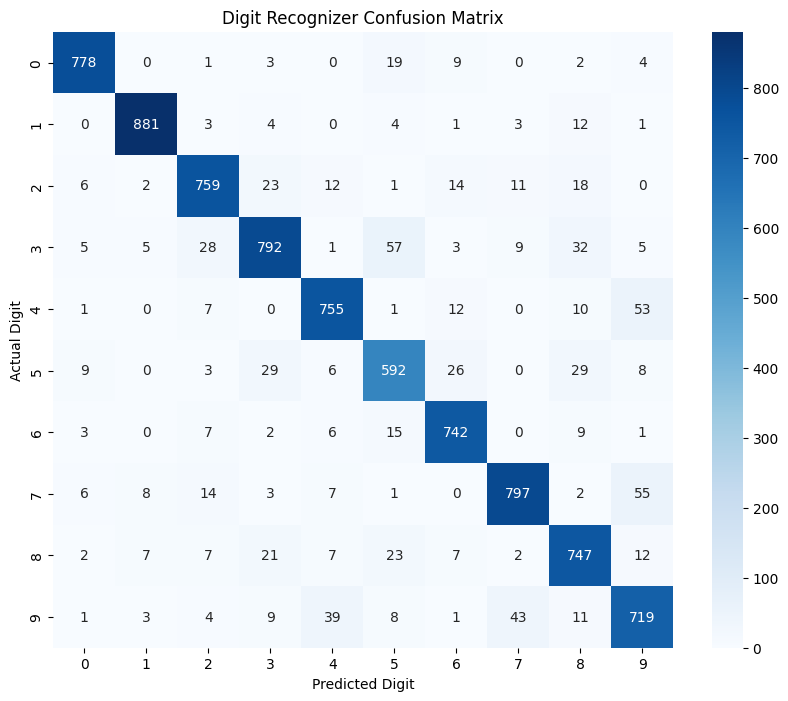

In [25]:
cm = confusion_matrix(y_test_np, pred_np)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.title('Digit Recognizer Confusion Matrix')
plt.show()

In [13]:
print(classification_report(y_test_np, pred_np))

              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       816
         1.0       0.97      0.98      0.98       909
         2.0       0.92      0.91      0.91       846
         3.0       0.92      0.89      0.90       937
         4.0       0.91      0.94      0.92       839
         5.0       0.89      0.90      0.90       702
         6.0       0.93      0.95      0.94       785
         7.0       0.94      0.91      0.93       893
         8.0       0.91      0.90      0.91       835
         9.0       0.90      0.91      0.90       838

    accuracy                           0.93      8400
   macro avg       0.93      0.93      0.93      8400
weighted avg       0.93      0.93      0.93      8400

